---
## Exploring Homogeneity assessment
#### 6/30/26
---

In [ ]:
# kernel: pangeo23

In [1]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

os.chdir('/home/nsiegert/projects/coastal_sst/code/analysis')
from coastal_analysis_fns import *

In [2]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [3]:
script = os.getcwd() + 'FigS2S3_resubmissionJun26_homog_test_implementfromHadISD_Fig1.ipynb'

In [4]:
# dataframe with the stations we are currently using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [5]:
# read in the temperature breaks dataframe
t_breaks = pd.read_fwf('/home/nsiegert/projects/coastal_sst/data/MergedBreaks_temperatures_hadisd.dat', 
                      names=['STAID', 'a', 'BREAKDATE', 'b', 'break_mo_mean', 'c', 'break_mo_diurnalrange'], 
                      widths=[12, 1, 10, 1, 6, 1, 6])

t_breaks = t_breaks.drop(['a', 'b', 'c'], axis=1)
t_breaks['BREAKDATE'] = pd.to_datetime(t_breaks['BREAKDATE'])
t_breaks

,STAID,BREAKDATE,break_mo_mean,break_mo_diurnalrange
0,010010-99999,1979-03-01,-99.99,0.23
1,010030-99999,2000-03-01,-99.99,-0.82
2,010030-99999,2004-12-01,-1.00,-99.99
3,010030-99999,2009-12-01,-99.99,-0.55
4,010030-99999,2019-09-01,0.57,-99.99
...,...,...,...,...
28050,A00017-04868,2006-10-01,0.39,-99.99
28051,A00017-04868,2013-01-01,0.63,-99.99
28052,A00019-53969,2011-02-01,-0.44,-99.99
28053,A00019-53969,2014-02-01,-99.99,0.39


In [6]:
# read in the dewpoint breaks dataframe
td_breaks = pd.read_fwf('/home/nsiegert/projects/coastal_sst/data/MergedBreaks_dewpoints_hadisd.dat', 
                      names=['STAID', 'a', 'BREAKDATE', 'b', 'break_mo_mean', 'c', 'break_mo_diurnalrange'], 
                      widths=[12, 1, 10, 1, 6, 1, 6])

td_breaks = td_breaks.drop(['a', 'b', 'c'], axis=1)
td_breaks['BREAKDATE'] = pd.to_datetime(td_breaks['BREAKDATE'])
td_breaks

,STAID,BREAKDATE,break_mo_mean,break_mo_diurnalrange
0,010010-99999,1979-03-01,-0.76,-99.99
1,010010-99999,1989-04-01,-1.46,-99.99
2,010010-99999,1994-08-01,1.44,-99.99
3,010010-99999,1998-02-01,-0.81,0.55
4,010010-99999,2000-05-01,-99.99,-0.37
...,...,...,...,...
36196,A00017-04868,2011-02-01,-99.99,0.56
36197,A00017-04868,2014-02-01,0.73,-99.99
36198,A00019-53969,2011-01-01,0.66,-99.99
36199,A00019-53969,2014-12-01,1.65,-1.52


In [7]:
# set maximum inhomogeneity magnitudes of 2, 1, and 0.5˚C, for both monthly mean or diurnal range

In [8]:
# mask out missing breaks
nonmissing_mask_T = t_breaks.break_mo_mean > -99
nonmissing_mask_Td = td_breaks.break_mo_mean > -99

# time mask (inhomogeneity needs to occur between 1990 and 2023
date_mask_T = (t_breaks.BREAKDATE >= pd.to_datetime('1990-01-01')) * (t_breaks.BREAKDATE <= pd.to_datetime('2023-12-31'))
date_mask_Td = (td_breaks.BREAKDATE >= pd.to_datetime('1990-01-01')) * (td_breaks.BREAKDATE <= pd.to_datetime('2023-12-31'))

# for each cutoff
for cutoff in [2, 1, 0.5]:

    # make masks of inhomogeneities based on ˚ cutoff
    inhomog_T_mask = np.abs(t_breaks.break_mo_mean) > cutoff
    inhomog_Td_mask = np.abs(td_breaks.break_mo_mean) > cutoff

    # to ID stations to mask out --> select any stations with non-missing T or Td inhomogeneities that are within the date ranges
    T_mask_out = inhomog_T_mask * nonmissing_mask_T * date_mask_T
    Td_mask_out = inhomog_Td_mask * nonmissing_mask_Td * date_mask_Td

    # gen "bad" staid's from this (doing separately for T and Td b/c they are different lengths)
    T_bad_staids = t_breaks[T_mask_out].STAID.unique()
    Td_bad_staids = td_breaks[Td_mask_out].STAID.unique()

    # pool the lists "bad" STAID's across the 2 variables, take unique
    bad_staids_both = np.unique(T_bad_staids.tolist() + Td_bad_staids.tolist())
    
    # find how many of OUR STAID's should be excluded
    bad_staids_in_our_sample = gdf.STAID.isin(bad_staids_both)
    bad_staids_in_our_sample_T = gdf.STAID.isin(T_bad_staids)
    bad_staids_in_our_sample_Td = gdf.STAID.isin(Td_bad_staids)
    
    gdf['inhomog_{}'.format(cutoff)] = bad_staids_in_our_sample
    gdf['inhomog_{}_T'.format(cutoff)] = bad_staids_in_our_sample_T
    gdf['inhomog_{}_Td'.format(cutoff)] = bad_staids_in_our_sample_Td

    # print
    print('Cutoff: {}˚C, Both: {} T: {} Td: {}'.format(cutoff, np.sum(bad_staids_in_our_sample), np.sum(bad_staids_in_our_sample_T), np.sum(bad_staids_in_our_sample_Td)))

Cutoff: 2˚C, Both: 140 T: 19 Td: 129
Cutoff: 1˚C, Both: 583 T: 181 Td: 513
Cutoff: 0.5˚C, Both: 1089 T: 546 Td: 975


In [9]:
# save to dataframe as well
pd.DataFrame(gdf).to_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded_withHomogTest.csv')

In [10]:
tx_inhomog2_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_2_T'].to_numpy())
tx_inhomog1_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_1_T'].to_numpy())

td_inhomog2_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_2_Td'].to_numpy())
td_inhomog1_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 10), lats=gdf['LAT'].to_numpy(), dat=gdf['inhomog_1_Td'].to_numpy())

stations in red are eliminated with a 2˚ inhomogeneity criteria, blue are eliminated with a 1˚C cutoff criteria
Maybe add this to Fig. S1


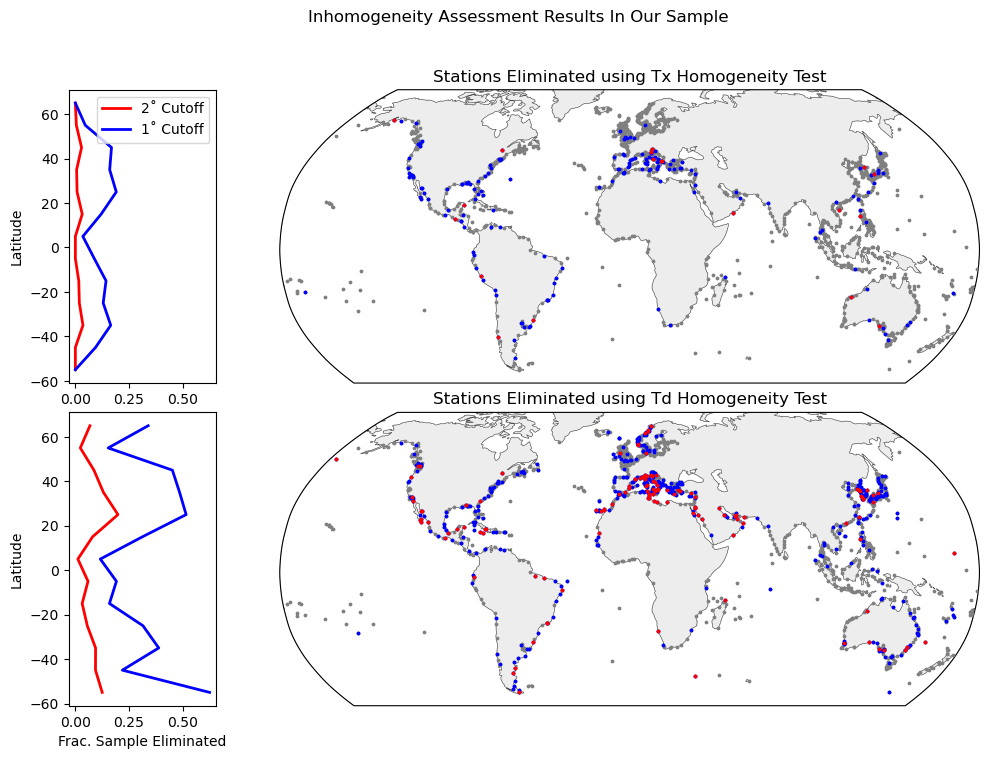

In [11]:
# setup axes
nrows = 2
ncols = 2
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 5]) 
gs.update(wspace=0.1, hspace=0.1)

## Plot data
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())

ax2 = fig.add_subplot(gs[1,0], sharex=ax0)
ax3 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())

# ax0 - average fraction of stations eliminated per lat bin
ax0.plot(tx_inhomog2_binned, bin_midpoints, color='r', lw=2, label='2˚ Cutoff')
ax0.plot(tx_inhomog1_binned, bin_midpoints, color='b', lw=2, label='1˚ Cutoff')
ax0.set(ylabel='Latitude', xlabel='')
ax0.legend()


## ax1 = map of T inhomogeneities
gdf.plot(ax=ax1, transform=ccrs.PlateCarree(), markersize=3, zorder=10, color='grey')
gdf[gdf['inhomog_1_T']].plot(ax=ax1, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='blue')
gdf[gdf['inhomog_2_T']].plot(ax=ax1, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='red')
ax1.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.set(title='Stations Eliminated using Tx Homogeneity Test')

# ax2 - average fraction of (Td) stations eliminated per lat bin
ax2.plot(td_inhomog2_binned, bin_midpoints, color='r', lw=2, label='2˚ Cutoff')
ax2.plot(td_inhomog1_binned, bin_midpoints, color='b', lw=2, label='1˚ Cutoff')
ax2.set(ylabel='Latitude', xlabel='Frac. Sample Eliminated')

## ax3 = map of T inhomogeneities
gdf.plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=10, color='grey')
gdf[gdf['inhomog_1_Td']].plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='blue')
gdf[gdf['inhomog_2_Td']].plot(ax=ax3, transform=ccrs.PlateCarree(), markersize=3, zorder=12, color='red')
ax3.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.set(title='Stations Eliminated using Td Homogeneity Test')

plt.suptitle('Inhomogeneity Assessment Results In Our Sample')
print('stations in red are eliminated with a 2˚ inhomogeneity criteria, blue are eliminated with a 1˚C cutoff criteria')
print('Maybe add this to Fig. S1')

# could add color bar = abs() "size of breaks" perhaps...

plt.show()

In [27]:
print('hello')

hello


In [29]:
print('N SAMPLE, 2˚ CUTOFFS: T {} Td {}'.format(np.sum(gdf['inhomog_2_T']), np.sum(gdf['inhomog_2_Td'])))
print('N SAMPLE, 1˚ CUTOFFS: T {} Td {}'.format(np.sum(gdf['inhomog_1_T']), np.sum(gdf['inhomog_1_Td'])))

N SAMPLE, 2˚ CUTOFFS: T 19 Td 129
N SAMPLE, 1˚ CUTOFFS: T 181 Td 513


In [34]:
len(gdf) - 513

961

# replicate Fig. 1 after eliminating stations in 2 rounds of inhomogeneity cutoffs

In [12]:
# open geophysical data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW.data.astype(bool)

# station var's
tx_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.detrend_anom.roll11.nc').Tx # note new filename 11/21
td_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.detrend_anom.roll11.nc').Td # note new filename 11/21

# tmean (raw)
tx_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.nc').Tx
tn_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tn.nc').Tn
tmean_da = (tx_raw_da + tn_raw_da) / 2

# raw dewpoint
td_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.nc').Td

# SST 
sst_da = xr.open_dataset('/dx02/data/nsiegert/oisst_station_cirleavg/ALLSTATIONS.1.5deg.daily.sst.1.9.2025.nc').sst.sel(time=slice('1990-01-01', '2023-12-31'))
sst_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.sst.detrend_anom.roll11.nc').sst.sel(time=slice('1990-01-01', '2023-12-31')) # note new filename 11/21

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

# Analysis

In [13]:
from scipy.spatial import cKDTree

In [14]:
def compute_density_weights(lats, lons, radius_deg=5.0):
    """
    Inverse density weights for stations within a latitude band.
    Uses KD-tree to count neighbors within radius_deg.

    inputs: list of lats, lons, and radius (in ˚) for which to look for neighbors. depends on what spatial scale you think is important
    """
    # Approximate planar distance in degrees (fine within a narrow lat band)
    coords = np.column_stack([lats, lons])
    tree = cKDTree(coords)
    
    # Count neighbors within radius (incl. self)
    neighbor_counts = np.array([len(tree.query_ball_point(pt, radius_deg)) for pt in coords])
    
    weights = 1.0 / neighbor_counts
    
    return weights / weights.sum()  # normalize to sum to 1

In [15]:
def bin_lat_scatters_densitywtd_bootCI(latbins, lats, lons, dat, nboot, radius_deg):
    '''
    like bin_lat_scatters, but within each lat-bin I'm doing nboot bootstrapped means 
        (sampled with replacement) and weighted by inverse of station density (to try to
        counteract the effect of station spatial clustering/autocorrelation on the lat-bin-mean)

    new input params: lons, nboot, radius_deg (what the density radius of autocorr. is that you care about    
    
    returns: median, 97.5, and 2.5 %ile estimates for bootstrapped means, the entire array of 1k bootstrap iterations, bin midpoints, and bin num. obs. 

    6/18/26
    '''

    # random seed
    rng = np.random.default_rng(27)

    # empty arrays to hold output
    binned_boots = np.zeros(shape=(len(latbins)-1, nboot)) * np.nan # dims = [lat_bin, bootstrap_mean_draw]
    bin_midpoints = np.zeros(len(latbins)-1)
    bin_n_obs = np.zeros(len(latbins)-1)
    
    i = 0
    
    no_inf_mask = np.logical_not(np.isinf(dat)) # 5/9

    # for each lat bin
    while i < len(latbins)-1:

        # sel lat bin bounds, generate bin mask
        bot_bin = latbins[i]
        top_bin = latbins[i+1]
        binmask = (lats >= bot_bin) * (lats < top_bin)

#        print(i, bot_bin, top_bin)

        # skip bin if there are no obs in that bin
        if np.sum(binmask) == 0:
#            print('skip this bin.')
            bin_midpoints[i] = ((bot_bin+top_bin)/2)
            bin_n_obs[i] = 0
            i += 1
            continue

        # set vals to send to bootstrap
        dat_bin = dat[binmask]
        lats_bin = lats[binmask]
        lons_bin = lons[binmask]

        # distance-weights for this lat bin
        weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)

        # empty array to store bootstrap draws
        boot_stats = (np.zeros(nboot) * np.nan)

        # do the bootstrapped mean
        for b in range(nboot):
            idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
            boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean

        # add the results to the output arrays
        binned_boots[i, :] = boot_stats
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = np.sum(binmask)

        # update counter var
        i += 1


    
    return np.quantile(binned_boots, 0.5, axis=1), np.quantile(binned_boots, 0.975, axis=1), np.quantile(binned_boots, 0.025, axis=1), binned_boots, bin_midpoints, bin_n_obs

In [16]:
### Do things that I compute for all stations first, before applying homogeneity masks and averaging within lat bins

In [17]:
## average Tx and td anom's during coastal MHW days 


# create MHW composites of important var's and add to gdf so we can plot

# station-mean (detrended anom) Tmax for MHW days and all days, for all szn, cold szn, and warm szn
gdf['Tx_det_mean'] = tx_det_da.mean(dim='time')
gdf['Tx_det_mean_w'] = tx_det_da.where(warmszn_mask).mean(dim='time')
gdf['Tx_det_mean_c'] = tx_det_da.where(coldszn_mask).mean(dim='time')
gdf['Tx_det_mhw_mean'] = tx_det_da.where(mhw_mask).mean(dim='time')
gdf['Tx_det_mhw_mean_w'] = tx_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['Tx_det_mhw_mean_c'] = tx_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

# station-mean (detrended anom) Dewpoint for MHW days and all days, for all szn, cold szn, and warm szn
gdf['Td_det_mean'] = td_det_da.mean(dim='time')
gdf['Td_det_mean_w'] = td_det_da.where(warmszn_mask).mean(dim='time')
gdf['Td_det_mean_c'] = td_det_da.where(coldszn_mask).mean(dim='time')
gdf['Td_det_mhw_mean'] = td_det_da.where(mhw_mask).mean(dim='time')
gdf['Td_det_mhw_mean_w'] = td_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['Td_det_mhw_mean_c'] = td_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

In [18]:
# generate mask for terrestrial tx, td, and HI < 10th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.1)
tx10_mask = tx_raw_da.groupby("time.dayofyear") <= hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.1)
td10_mask = td_raw_da.groupby("time.dayofyear") <= hk

# generate mask for terrestrial tx, td > 90th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.9)
tx90_mask = tx_raw_da.groupby("time.dayofyear") > hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.9)
td90_mask = td_raw_da.groupby("time.dayofyear") > hk

In [19]:
#%%time
# compute these curves for each station individually (that's what's happening in this cell)

## embarrassingly parallelizeable code... (takes ~1 min)

print('starting')
sstbins = np.arange(0, 1.1, 0.1)

# arrays to hold output
sstbinned_tx90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_tx90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_c = np.zeros(shape=(10, len(gdf)))

sstbinned_td90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_td90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_td90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_td10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_c = np.zeros(shape=(10, len(gdf)))

# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
    print(i, sstbins[i], sstbins[i+1])
    
    # generate mask for SST falling within that quantile range
    loqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i])
    hiqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i+1])
    sst_bin_mask = (sst_da.groupby("time.dayofyear") >= loqtiles) * (sst_da.groupby("time.dayofyear") < hiqtiles)
    
    # WITHIN THAT SST BIN: compute frequequency of exceeding Tx 90th %ile or being lower than Tx 10th %ile (also for warm and cold seasons)
    sstbinned_tx90_all[i,:] = tx90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx90_w[i,:] = tx90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx90_c[i,:] = tx90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

    sstbinned_tx10_all[i,:] = tx10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx10_w[i,:] = tx10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx10_c[i,:] = tx10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    # ALSO WITHIN THAT SST BIN: compute frequequency of exceeding Td 90th %ile or being lower than Td 10th %ile (also for warm and cold seasons)
    sstbinned_td90_all[i,:] = td90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td90_w[i,:] = td90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td90_c[i,:] = td90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    sstbinned_td10_all[i,:] = td10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td10_w[i,:] = td10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td10_c[i,:] = td10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

print('done')

starting
0 0.0 0.1
1 0.1 0.2
2 0.2 0.30000000000000004
3 0.30000000000000004 0.4
4 0.4 0.5
5 0.5 0.6000000000000001
6 0.6000000000000001 0.7000000000000001
7 0.7000000000000001 0.8
8 0.8 0.9
9 0.9 1.0
done


In [20]:
latprofile_dict = {}

BIG_GDF = gdf

for LOOP in range(2):

    if LOOP==0:
        # select all locations that do NOT have inhomogeneities of <cutoff> ˚C for T and dewpoint
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_2_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_2_Td']).to_numpy()
        cutoff = 2
    elif LOOP==1:
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_1_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_1_Td']).to_numpy()
        cutoff = 1

    latprofile_dict[cutoff] = {}
        
    # binned lat profiles of tx and td - this time using the density-weighted bootstrap resampling within each bin. 
    # a 3˚ bin sorta seems to be where the CI's stabilize...
    tx_mhw_w_binboot_med, tx_mhw_w_binboot_hi, tx_mhw_w_binboot_lo, tx_mhw_binboots_w, bin_midpoints, \
        bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                              lats=gdf_T['LAT'].to_numpy(), lons=gdf_T['LON'].to_numpy(), 
                                                              dat=gdf_T['Tx_det_mhw_mean_w'].to_numpy(), nboot=1000, radius_deg=3.0)
    
    latprofile_dict[cutoff]['tx_mhw_w_binboot_med'] = tx_mhw_w_binboot_med
    latprofile_dict[cutoff]['tx_mhw_w_binboot_hi'] = tx_mhw_w_binboot_hi
    latprofile_dict[cutoff]['tx_mhw_w_binboot_lo'] = tx_mhw_w_binboot_lo

    
    tx_mhw_c_binboot_med, tx_mhw_c_binboot_hi, tx_mhw_c_binboot_lo, tx_mhw_binboots_c, bin_midpoints, \
        bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                              lats=gdf_T['LAT'].to_numpy(), lons=gdf_T['LON'].to_numpy(), 
                                                              dat=gdf_T['Tx_det_mhw_mean_c'].to_numpy(), nboot=1000, radius_deg=3.0)
    
    latprofile_dict[cutoff]['tx_mhw_c_binboot_med'] = tx_mhw_c_binboot_med
    latprofile_dict[cutoff]['tx_mhw_c_binboot_hi'] = tx_mhw_c_binboot_hi
    latprofile_dict[cutoff]['tx_mhw_c_binboot_lo'] = tx_mhw_c_binboot_lo
    
    td_mhw_w_binboot_med, td_mhw_w_binboot_hi, td_mhw_w_binboot_lo, td_mhw_binboots_w, bin_midpoints, \
        bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                              lats=gdf_Td['LAT'].to_numpy(), lons=gdf_Td['LON'].to_numpy(), 
                                                              dat=gdf_Td['Td_det_mhw_mean_w'].to_numpy(), nboot=1000, radius_deg=3.0)

    latprofile_dict[cutoff]['td_mhw_w_binboot_med'] = td_mhw_w_binboot_med
    latprofile_dict[cutoff]['td_mhw_w_binboot_hi'] = td_mhw_w_binboot_hi
    latprofile_dict[cutoff]['td_mhw_w_binboot_lo'] = td_mhw_w_binboot_lo
    
    td_mhw_c_binboot_med, td_mhw_c_binboot_hi, td_mhw_c_binboot_lo, td_mhw_binboots_c, bin_midpoints, \
        bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                              lats=gdf_Td['LAT'].to_numpy(), lons=gdf_Td['LON'].to_numpy(), 
                                                              dat=gdf_Td['Td_det_mhw_mean_c'].to_numpy(), nboot=1000, radius_deg=3.0)

    latprofile_dict[cutoff]['td_mhw_c_binboot_med'] = td_mhw_c_binboot_med
    latprofile_dict[cutoff]['td_mhw_c_binboot_hi'] = td_mhw_c_binboot_hi
    latprofile_dict[cutoff]['td_mhw_c_binboot_lo'] = td_mhw_c_binboot_lo

/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


In [21]:
## For every coastal SST decile (bin), what is the frequency of being in < Var > threshold?

frequency_dict = {}

for LOOP in range(2):

    if LOOP==0:
        # select all locations that do NOT have inhomogeneities of <cutoff> ˚C for T and dewpoint
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_2_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_2_Td']).to_numpy()
        cutoff = 2
    elif LOOP==1:
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_1_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_1_Td']).to_numpy()
        cutoff = 1
        
    frequency_dict[cutoff] = {}

    ## Generate regionally stratified bootstrapped global means and CI's (what's happening in this cell)

    # for every coastal SST decile bin AND 3˚ latitude bin, I will get 1k bootstrapped mean values for the frequency of <var> > 90%ile.
        # then, I will area-weight-average the lat-bins together to get 1k globally stratified-resampled bootstrap means for 
                #[frequency of <var> in 90%ile given the coastal SST decile]
        # then, I can take the median and 95% CI of those 1k global bootstrapped means. 
    
    # generate land-area weights based on lat-bin width
    wts = np.cos(np.deg2rad(bin_midpoints))
    wts_da = xr.DataArray(wts, dims=['binlat'], coords={'binlat':bin_midpoints})
    
    # empty arrays to hold outputs
    sstbinned_tx90_bootmeds_w = np.zeros(10) * np.nan
    sstbinned_tx90_hicis_w = np.zeros(10) * np.nan
    sstbinned_tx90_locis_w = np.zeros(10) * np.nan 
    
    sstbinned_td90_bootmeds_w = np.zeros(10) * np.nan
    sstbinned_td90_hicis_w = np.zeros(10) * np.nan
    sstbinned_td90_locis_w = np.zeros(10) * np.nan 
    
    sstbinned_tx90_bootmeds_c = np.zeros(10) * np.nan
    sstbinned_tx90_hicis_c = np.zeros(10) * np.nan
    sstbinned_tx90_locis_c = np.zeros(10) * np.nan 
    
    sstbinned_td90_bootmeds_c = np.zeros(10) * np.nan
    sstbinned_td90_hicis_c = np.zeros(10) * np.nan
    sstbinned_td90_locis_c = np.zeros(10) * np.nan 
    
    
    # for each SST bin (quantiles 0-10)
    for i in range(10):
    
        print('sst bin: {}'.format(i))
    
        # for outcome var = tx>90%ile and td>90%ile in both warm and cold seasons
        for j, in_var in enumerate([sstbinned_tx90_w[i,Tmsk_arr], sstbinned_td90_w[i,Tdmsk_arr], sstbinned_tx90_c[i,Tmsk_arr], sstbinned_td90_c[i,Tdmsk_arr]]):

            # set latitudes/lons depending on if we are using T or Td input data
            if j==0 or j==2:
                lats1 = gdf_T.LAT.to_numpy()
                lons1 = gdf_T.LON.to_numpy()
            else:
                lats1 = gdf_Td.LAT.to_numpy()
                lons1 = gdf_Td.LON.to_numpy()

            ## do the binning
            # do a global bootstrap resampling for that SST bin (don't want the medians and ci's for this so will name the fn. ouptut as irrelevant things)
            aa, bb, cc, sstbinned_var90_w_allboots, \
                bin_midpoints, bin_nobs = bin_lat_scatters_densitywtd_bootCI(latbins=np.arange(-60, 71, 3), 
                                                                  lats=lats1, lons=lons1, 
                                                                  dat=in_var, nboot=1000, radius_deg=3.0)
        
            # put into xarray dataArray b/c it's easier for me to take weighted means and ignore Nan's
            da = xr.DataArray(sstbinned_var90_w_allboots, dims=['binlat', 'boot'], coords={'binlat':bin_midpoints, 'boot':np.array(range(0, 1000))})
        
            # take area-weighted mean, now generating 1000 region-stratified bootstrapped means, from which to draw 95% CI
            global_boot_means = da.weighted(wts_da).mean(dim='binlat')
        
            # now get medians and 95% CI
            if j==0:
                sstbinned_tx90_bootmeds_w[i] = np.quantile(global_boot_means, 0.5)
                sstbinned_tx90_hicis_w[i] = np.quantile(global_boot_means, 0.975)
                sstbinned_tx90_locis_w[i] = np.quantile(global_boot_means, 0.025)
            elif j==1:
                sstbinned_td90_bootmeds_w[i] = np.quantile(global_boot_means, 0.5)
                sstbinned_td90_hicis_w[i] = np.quantile(global_boot_means, 0.975)
                sstbinned_td90_locis_w[i] = np.quantile(global_boot_means, 0.025)
            elif j==2:
                sstbinned_tx90_bootmeds_c[i] = np.quantile(global_boot_means, 0.5)
                sstbinned_tx90_hicis_c[i] = np.quantile(global_boot_means, 0.975)
                sstbinned_tx90_locis_c[i] = np.quantile(global_boot_means, 0.025)
            elif j==3:
                sstbinned_td90_bootmeds_c[i] = np.quantile(global_boot_means, 0.5)
                sstbinned_td90_hicis_c[i] = np.quantile(global_boot_means, 0.975)
                sstbinned_td90_locis_c[i] = np.quantile(global_boot_means, 0.025)

    # save into dict. code is rough. 
    frequency_dict[cutoff]['sstbinned_tx90_bootmeds_w'] = sstbinned_tx90_bootmeds_w
    frequency_dict[cutoff]['sstbinned_tx90_hicis_w'] = sstbinned_tx90_hicis_w
    frequency_dict[cutoff]['sstbinned_tx90_locis_w'] = sstbinned_tx90_locis_w

    frequency_dict[cutoff]['sstbinned_td90_bootmeds_w'] = sstbinned_td90_bootmeds_w
    frequency_dict[cutoff]['sstbinned_td90_hicis_w'] = sstbinned_td90_hicis_w
    frequency_dict[cutoff]['sstbinned_td90_locis_w'] = sstbinned_td90_locis_w

    frequency_dict[cutoff]['sstbinned_tx90_bootmeds_c'] = sstbinned_tx90_bootmeds_c
    frequency_dict[cutoff]['sstbinned_tx90_hicis_c'] = sstbinned_tx90_hicis_c
    frequency_dict[cutoff]['sstbinned_tx90_locis_c'] = sstbinned_tx90_locis_c

    frequency_dict[cutoff]['sstbinned_td90_bootmeds_c'] = sstbinned_td90_bootmeds_c
    frequency_dict[cutoff]['sstbinned_td90_hicis_c'] = sstbinned_td90_hicis_c
    frequency_dict[cutoff]['sstbinned_td90_locis_c'] = sstbinned_td90_locis_c


sst bin: 0
sst bin: 1
sst bin: 2
sst bin: 3
sst bin: 4
sst bin: 5
sst bin: 6
sst bin: 7
sst bin: 8
sst bin: 9
sst bin: 0


/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean
/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


sst bin: 1


/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean
/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


sst bin: 2


...

/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean
/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


sst bin: 8


/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean
/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


sst bin: 9


/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean
/tmp/ipykernel_130828/539044789.py:58: RuntimeWarning: Mean of empty slice
  boot_stats[b] = np.nanmean(dat_bin[idx]) # don't think I need nanmean


# plot - for both inhomogeneity cutoff levels

### Tx and Td Anomalies during coastal MHW conditions

In [22]:
# I have: latprofile_dict and frequency_dict

In [23]:
# set cmap
vmin = 0
vmax = 2.5
ncol_i = 6
bounds_i = np.linspace(vmin, vmax, ncol_i)
bluecolors = plt.get_cmap('Blues')(np.linspace(0,1,21))
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_i)+1))
cmap_i = colors.ListedColormap(cols[1:-1])
cmap_i.set_over(cols[-1])
cmap_i.set_under(bluecolors[-4])
norm_i = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

Figure 1 Draft, Redone Eliminating Stations with T or Td Inhomogeneities of >= 2˚C


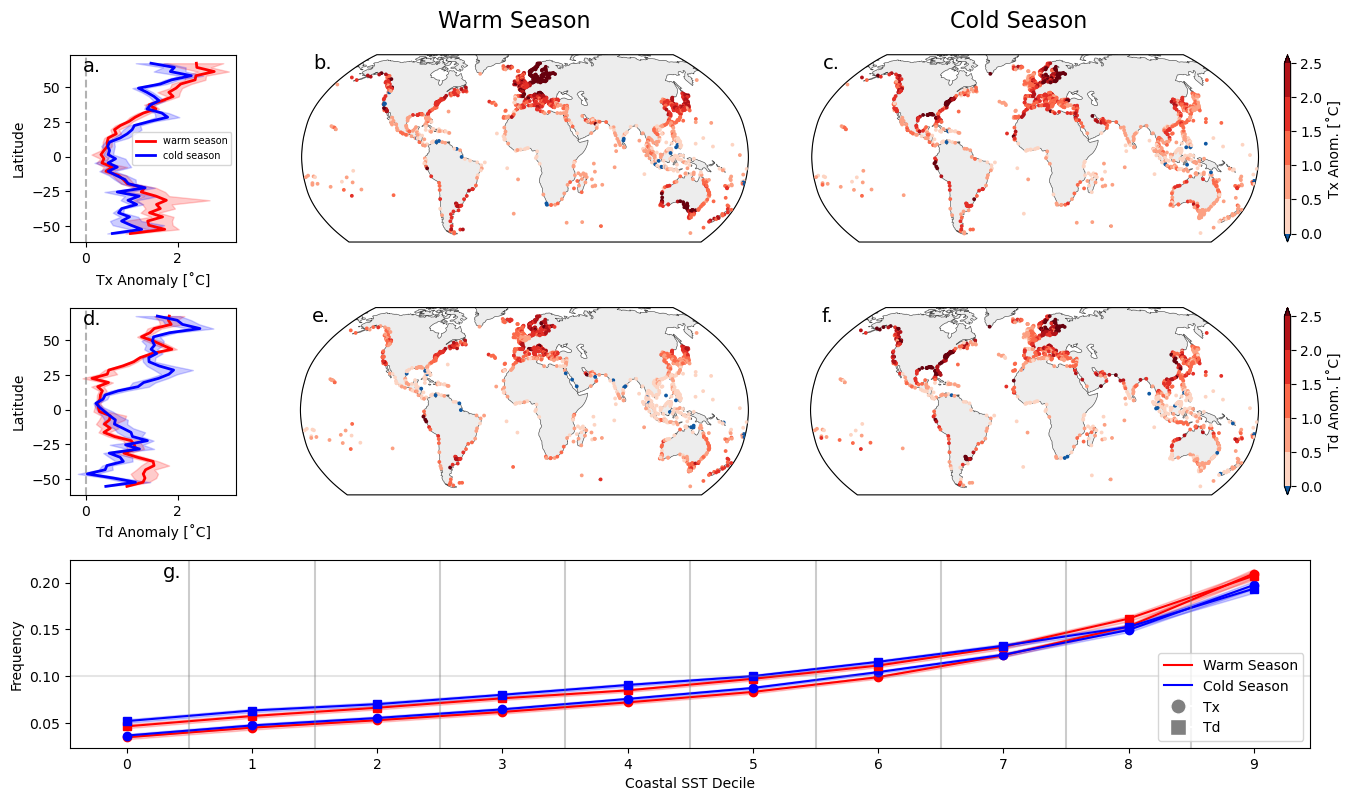


Figure 1 Draft, Redone Eliminating Stations with T or Td Inhomogeneities of >= 1˚C


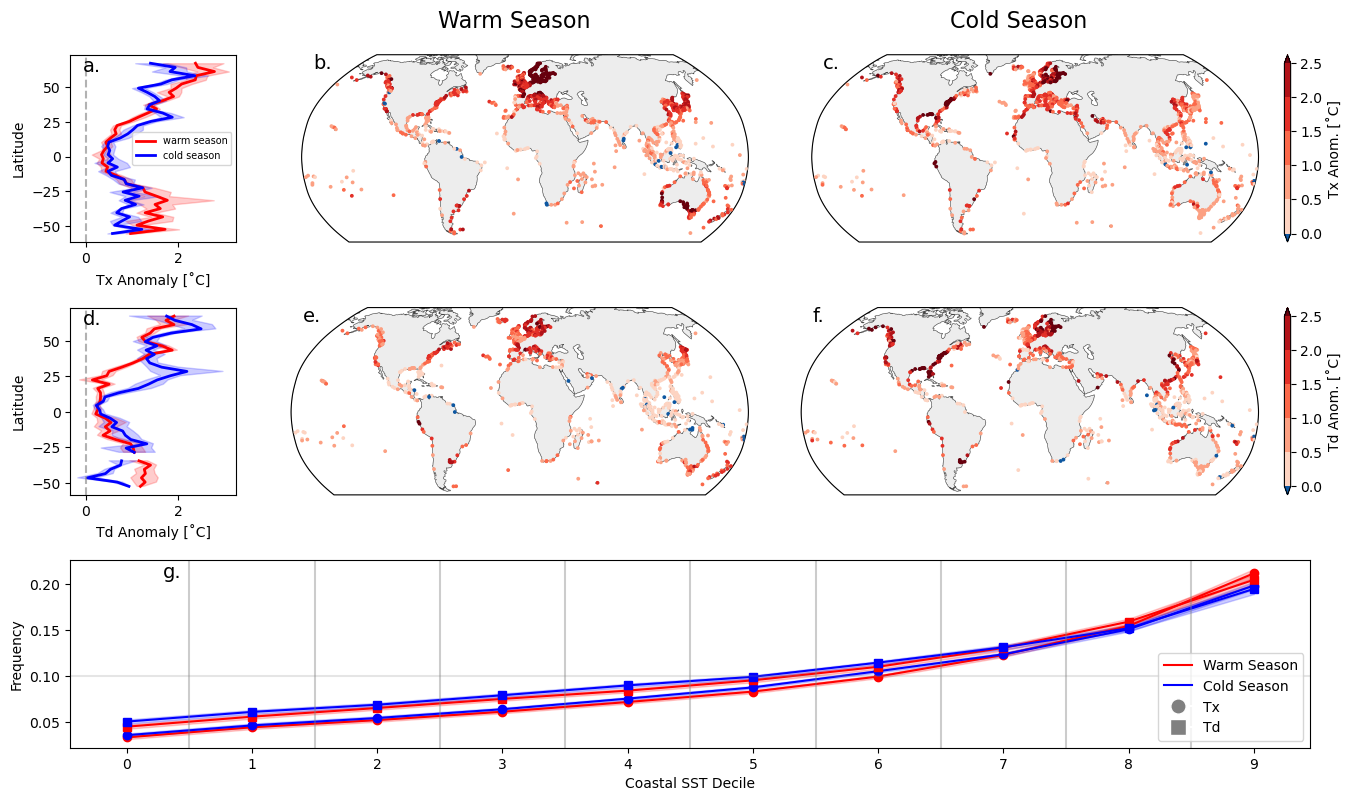

In [25]:
for LOOP in range(2):

    if LOOP==0:
        # select all locations that do NOT have inhomogeneities of <cutoff> ˚C for T and dewpoint
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_2_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_2_Td']).to_numpy()
        cutoff = 2
    elif LOOP==1:
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_T'])]
        gdf_Td = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_Td'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_1_T']).to_numpy()
        Tdmsk_arr = np.logical_not(BIG_GDF['inhomog_1_Td']).to_numpy()
        cutoff = 1


        
    ########
    # PLOT #
    ########

    # make A NEW version of the plot with region-stratified bootstrapped means and CI's June 2026
    
    
    # setup axes
    nrows = 3
    ncols = 3
    fig = plt.figure(figsize=(16, 9))
    gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 3, 3]) 
    gs.update(wspace=0.1, hspace=0.35)
    
    
    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
    ax2 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
    ax3 = fig.add_subplot(gs[1,0], sharex=ax0)
    ax4 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())
    ax5 = fig.add_subplot(gs[1,2], projection=ccrs.Robinson())
    ax6 = fig.add_subplot(gs[2,:])
    
    ## ROW 0
    # ax0: lat profiles for Tx
    ax0.plot(latprofile_dict[cutoff]['tx_mhw_w_binboot_med'], bin_midpoints, color='r', label='warm season', lw=2) # warm-season mean
    ax0.fill_betweenx(y=bin_midpoints, x1=latprofile_dict[cutoff]['tx_mhw_w_binboot_lo'], x2=latprofile_dict[cutoff]['tx_mhw_w_binboot_hi'], color='r', alpha=0.2) # warm-season CI
    
    ax0.plot(latprofile_dict[cutoff]['tx_mhw_c_binboot_med'], bin_midpoints, color='b', label='cold season', lw=2) # cold-season mean
    ax0.fill_betweenx(y=bin_midpoints, x1=latprofile_dict[cutoff]['tx_mhw_c_binboot_lo'], x2=latprofile_dict[cutoff]['tx_mhw_c_binboot_hi'], color='b', alpha=0.2) # cold-season CI
    
    ax0.set(ylabel='Latitude', xlabel='Tx Anomaly [˚C]')
    ax0.axvline(color='grey', ls='--', alpha=0.6)
    ax0.legend(fontsize=7)
    
    # ax1: map of Tx_mhw during warm season
    gdf_T.plot(column='Tx_det_mhw_mean_w', ax=ax1, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
    # ax2: map of Tx_mhw during cold season
    gdf_T.plot(column='Tx_det_mhw_mean_c', ax=ax2, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
        
    # cbar
    sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
    sm.set_array([])
    
    cbar = fig.colorbar(sm,  
                        ax=[ax1, ax2],
                        orientation="vertical",
                        extend='both',
                        label="Tx Anom. [˚C]",
                        pad=0.025,
                        use_gridspec=True,
                        fraction=0.025, 
                        ticks=bounds_i,
                        aspect=30)
    
    
    ## ROW 1
    # ax3: lat profiles for Td
    ax3.plot(latprofile_dict[cutoff]['td_mhw_w_binboot_med'], bin_midpoints, color='r', label='warm season', lw=2) # warm-season mean
    ax3.fill_betweenx(y=bin_midpoints, x1=latprofile_dict[cutoff]['td_mhw_w_binboot_lo'], x2=latprofile_dict[cutoff]['td_mhw_w_binboot_hi'], color='r', alpha=0.2) # warm-season CI
    
    ax3.plot(latprofile_dict[cutoff]['td_mhw_c_binboot_med'], bin_midpoints, color='b', label='cold season', lw=2) # cold-season mean
    ax3.fill_betweenx(y=bin_midpoints, x1=latprofile_dict[cutoff]['td_mhw_c_binboot_lo'], x2=latprofile_dict[cutoff]['td_mhw_c_binboot_hi'], color='b', alpha=0.2) # cold-season CI
    
    ax3.set(ylabel='Latitude', xlabel='Td Anomaly [˚C]')
    ax3.axvline(color='grey', ls='--', alpha=0.6)
    
    # ax4: Td_mhw during warm season
    gdf_Td.plot(column='Td_det_mhw_mean_w', ax=ax4, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
    # ax5: Td_mhw during cold season
    gdf_Td.plot(column='Td_det_mhw_mean_c', ax=ax5, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
        
    # cbar
    sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
    sm.set_array([])
    
    cbar = fig.colorbar(sm,  
                        ax=[ax4, ax5],
                        orientation="vertical",
                        extend='both',
                        label="Td Anom. [˚C]",
                        pad=0.025,
                        use_gridspec=True,
                        fraction=0.025, 
                        ticks=bounds_i,
                        aspect=30)
    
    
    # Map Cosmetics
    for ax in [ax1, ax2, ax4, ax5]:
        ax.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
        ax.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
    
    
    
    # ax6: <var> extreme vs. SST Decile
    xs = np.array(range(10))
    
    ax6.plot(xs, frequency_dict[cutoff]['sstbinned_tx90_bootmeds_w'], color='r', marker='o')
    ax6.fill_between(xs, frequency_dict[cutoff]['sstbinned_tx90_locis_w'], frequency_dict[cutoff]['sstbinned_tx90_hicis_w'], color='r', alpha=0.2)
    
    ax6.plot(xs, frequency_dict[cutoff]['sstbinned_tx90_bootmeds_c'], color='b', marker='o')
    ax6.fill_between(xs, frequency_dict[cutoff]['sstbinned_tx90_locis_c'], frequency_dict[cutoff]['sstbinned_tx90_hicis_c'], color='b', alpha=0.2)
    
    ax6.plot(xs, frequency_dict[cutoff]['sstbinned_td90_bootmeds_w'], color='r', marker='s')
    ax6.fill_between(xs, frequency_dict[cutoff]['sstbinned_td90_locis_w'], frequency_dict[cutoff]['sstbinned_td90_hicis_w'], color='r', alpha=0.2)
    
    ax6.plot(xs, frequency_dict[cutoff]['sstbinned_td90_bootmeds_c'], color='b', marker='s')
    ax6.fill_between(xs, frequency_dict[cutoff]['sstbinned_td90_locis_c'], frequency_dict[cutoff]['sstbinned_td90_hicis_c'], color='b', alpha=0.2)
        
    ax6.set_xticks(np.arange(0, 10, 1))
    ax6.set(title='', xlabel='Coastal SST Decile', ylabel='Frequency')
    
    # vertical line
    for l in np.arange(0.5, 8.6, 1):
        ax6.axvline(l, color='gray', alpha=0.4)
    
    ax6.axhline(0.1, color='grey', alpha=0.2)
        
    # legend
    legend_elements = [Line2D([0], [0], color='r', label='Warm Season'),
                       Line2D([0], [0], color='b', label='Cold Season'),
                       Line2D([0], [0], marker='o', color='w', label='Tx',
                              markerfacecolor='grey', markersize=11),
                       Line2D([0], [0], marker='s', color='w', label='Td',
                              markerfacecolor='grey', markersize=11)]
    
    ax6.legend(handles=legend_elements, loc='lower right')
    
    
    ## subplot labels
    letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
    
    i = 0
    for ax in [ax0, ax1, ax2, ax3, ax4, ax5, ax6]:
        if i==0 or i==3 or i==6:
            ax.text(s='{}.'.format(letters[i]), x=0.075, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)
        else:
            ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
        i += 1
    
    fig.text(x=0.355, y=0.91, s='Warm Season', fontsize=16)
    fig.text(x=0.675, y=0.91, s='Cold Season', fontsize=16)
    
    # now = datetime.now() # get datetime
    # fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
    # fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')
    
    # SAVE FIGURE
    # plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/Fig1_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')
#    plt.suptitle('Figure 1 Draft, Redone Eliminating Stations with T or Td Inhomogeneities of >= {}˚C'.format(cutoff))
    print('Figure 1 Draft, Redone Eliminating Stations with T or Td Inhomogeneities of >= {}˚C'.format(cutoff))

    plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigSX_coastalsst_grl_6_26_Fig1HomogTest_{}degCutoff.png'.format(cutoff), format='png', bbox_inches='tight')
    
    plt.show()
    
    print('')
    plt.pause(0.1)

In [26]:
print('hell0')

hell0
